In [1]:
import os
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation
from itertools import islice

from cryo_sbi import CryoEmSimulator
from cryo_sbi.inference.models import build_models
import cryo_sbi.inference.train_nle_model as train_nle_model
import cryo_sbi.inference.train_npe_model as train_npe_model
import cryo_sbi.utils.estimator_utils as est_utils
from cryo_sbi.inference.priors import get_image_priors, PriorLoader
import cryo_sbi.utils.image_utils as img_utils
from cryo_sbi.utils.visualize_models import plot_model

### Make the models 

Here we are creating a simple molecular model. 
In our model we will have four pseudo atoms arranged in a rectangle. The model differs between the sidelength we are using. The atoms are placed at the corners of the rectangle. The distance between the atoms is the same for all atoms.
The goal is then to simulate cryo-EM images with these models and infer the distance between the two atoms from the images.

The first step is to create the models. We start by crating an array with the side length `side_length` between the atoms. We will use this array to create the models.
The models are created by placing pseudo atoms at the corners of the rectangle.

The models are saved into teh file `models.pt`.



In [2]:
def generate_clamshell_models(n_models=20, n_atoms_per_lobe=200):
    """
    Generate two-lobe protein opening like a clamshell.
    Examples: Calmodulin, antibodies, ATP-binding proteins
    
    Args:
        n_models: Number of frames in the motion
        n_atoms_per_lobe: Number of points per lobe (will be adjusted to create grid)
    
    Returns:
        models: tensor of shape (n_models, 3, n_atoms_total)
    """
    opening_angles = torch.linspace(0, np.pi/3, n_models)  # 0° to 60° opening
    models = []
    
    # Create grid for proper ellipsoid surface
    n_theta = int(np.sqrt(n_atoms_per_lobe))
    n_phi = n_theta
    
    theta = torch.linspace(0, 2*np.pi, n_theta)
    phi = torch.linspace(0, np.pi, n_phi)
    theta_grid, phi_grid = torch.meshgrid(theta, phi, indexing='ij')
    theta_flat = theta_grid.flatten()
    phi_flat = phi_grid.flatten()
    
    for angle in opening_angles:
        # LOBE 1: Create ellipsoid using proper spherical coordinates
        r1_x = 6 * torch.sin(phi_flat) * torch.cos(theta_flat)
        r1_y = 3 * torch.sin(phi_flat) * torch.sin(theta_flat)
        r1_z = 2 * torch.cos(phi_flat)
        
        # Rotate lobe 1 around Z-axis (counterclockwise in XY plane)
        x1 = r1_x * torch.cos(angle) - r1_y * torch.sin(angle) - 5
        y1 = r1_x * torch.sin(angle) + r1_y * torch.cos(angle)
        z1 = r1_z
        
        # LOBE 2: Mirror lobe
        r2_x = 6 * torch.sin(phi_flat) * torch.cos(theta_flat)
        r2_y = 3 * torch.sin(phi_flat) * torch.sin(theta_flat)
        r2_z = 2 * torch.cos(phi_flat)
        
        # Rotate lobe 2 around Z-axis (clockwise in XY plane)
        x2 = r2_x * torch.cos(-angle) - r2_y * torch.sin(-angle) + 5
        y2 = r2_x * torch.sin(-angle) + r2_y * torch.cos(-angle)
        z2 = r2_z
        
        # Combine both lobes
        x = torch.cat([x1, x2])
        y = torch.cat([y1, y2])
        z = torch.cat([z1, z2])
        
        # Stack as (3, n_atoms_total)
        model = torch.stack([x, y, z])
        models.append(model)
    
    # Stack all models: (n_models, 3, n_atoms_total)
    models = torch.stack(models)
    return models

# Generate models
models = generate_clamshell_models(n_models=20, n_atoms_per_lobe=100)

In [3]:
models.shape
print(models.shape)

torch.Size([20, 3, 200])


In [4]:
def analyze_model_connectivity(models, cutoff=5.0):
    """
    Analyze how many atom pairs are within cutoff distance.
    
    Args:
        models: [num_models, 3, N] tensor
        cutoff: distance threshold
    
    Returns:
        Statistics about connectivity
    """
    # Transpose to [num_models, N, 3]
    coords = models.transpose(1, 2)
    
    num_models, N, _ = coords.shape
    
    edges_per_model = []
    
    for i in range(num_models):
        coord = coords[i]  # [N, 3]
        
        # Compute pairwise distances
        coord_i = coord.unsqueeze(1)  # [N, 1, 3]
        coord_j = coord.unsqueeze(0)  # [1, N, 3]
        dist = torch.norm(coord_i - coord_j, dim=-1)  # [N, N]
        
        # Count edges (excluding self-loops)
        mask = (dist < cutoff) & (~torch.eye(N, dtype=torch.bool, device=dist.device))
        num_edges = mask.sum().item()
        
        edges_per_model.append(num_edges)
    
    edges_per_model = np.array(edges_per_model)
    
    print(f"Cutoff: {cutoff}")
    print(f"Number of atoms (N): {N}")
    print(f"Max possible edges per model (excluding self): {N * (N - 1)}")
    print(f"\nEdges within cutoff:")
    print(f"  Mean: {edges_per_model.mean():.1f}")
    print(f"  Std: {edges_per_model.std():.1f}")
    print(f"  Min: {edges_per_model.min()}")
    print(f"  Max: {edges_per_model.max()}")
    print(f"  Density: {edges_per_model.mean() / (N * (N - 1)) * 100:.2f}%")
    
    return edges_per_model

# Test various cutoffs
for cutoff in [5.0, 10.0, 15.0, 20.0]:
    analyze_model_connectivity(models, cutoff)
    print("\n" + "="*50 + "\n")

Cutoff: 5.0
Number of atoms (N): 200
Max possible edges per model (excluding self): 39800

Edges within cutoff:
  Mean: 13219.2
  Std: 484.9
  Min: 12404
  Max: 13916
  Density: 33.21%


Cutoff: 10.0
Number of atoms (N): 200
Max possible edges per model (excluding self): 39800

Edges within cutoff:
  Mean: 27682.9
  Std: 554.7
  Min: 26492
  Max: 28372
  Density: 69.56%


Cutoff: 15.0
Number of atoms (N): 200
Max possible edges per model (excluding self): 39800

Edges within cutoff:
  Mean: 37657.6
  Std: 561.6
  Min: 37060
  Max: 38720
  Density: 94.62%


Cutoff: 20.0
Number of atoms (N): 200
Max possible edges per model (excluding self): 39800

Edges within cutoff:
  Mean: 39744.8
  Std: 59.9
  Min: 39640
  Max: 39800
  Density: 99.86%




In [5]:
def center_models(models):
    """
    Remove center of mass from each model.
    
    Args:
        models: torch.Tensor of shape [num_models, 3, N]
                where 3 = (x, y, z) and N = number of atoms
    
    Returns:
        centered_models: torch.Tensor of same shape, centered at origin
    """
    # Compute center of mass for each model
    # Mean over atoms (dim=2) -> [num_models, 3]
    com = models.mean(dim=2, keepdim=True)  # [num_models, 3, 1]
    
    # Subtract center of mass
    centered_models = models - com
    
    return centered_models

# center and save models
models = center_models(models)
torch.save(models, "models.pt")

In [6]:
models.shape

torch.Size([20, 3, 200])

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y

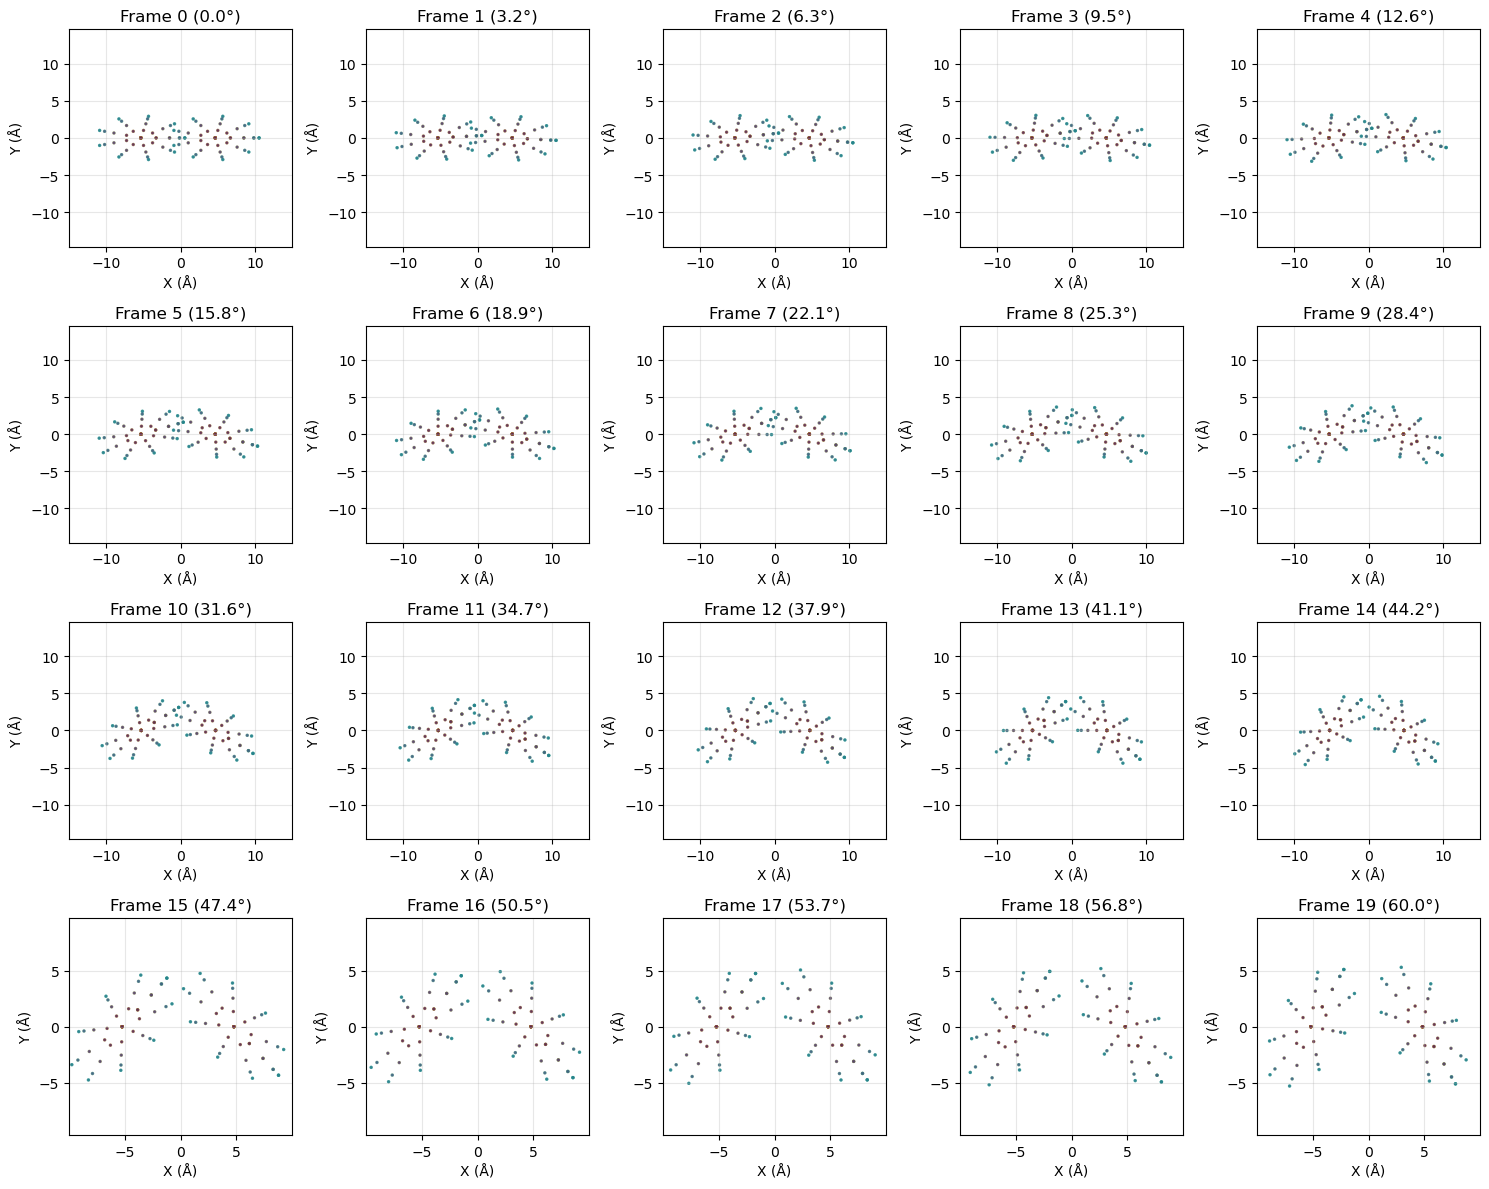

In [7]:
def plot_xy_projections(models):
    """
    Plot XY projection of all models, each in a separate panel
    
    Args:
        models: tensor of shape (n_models, 3, n_atoms_total)
    """
    n_models = models.shape[0]
    
    # Calculate grid dimensions (try to make it roughly square)
    n_cols = int(np.ceil(np.sqrt(n_models)))
    n_rows = int(np.ceil(n_models / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows))
    
    # Flatten axes array for easy indexing
    if n_models == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
    
    for i in range(n_models):
        x = models[i, 0, :].numpy()
        y = models[i, 1, :].numpy()
        z = models[i, 2, :].numpy()
        
        # Plot XY projection, color by Z coordinate
        axes[i].scatter(x, y, c=z, cmap='viridis', s=2, alpha=0.6)
        axes[i].set_xlabel('X (Å)')
        axes[i].set_ylabel('Y (Å)')
        axes[i].set_title(f'Frame {i} ({i/(n_models-1)*60:.1f}°)')
        axes[i].axis('equal')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlim([-15, 15])
        axes[i].set_ylim([-10, 10])
    
    # Hide empty subplots
    for i in range(n_models, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig('xy_projections.png', dpi=150, bbox_inches='tight')
    plt.show()

# Plot XY projections
plot_xy_projections(models)

### Run first simulation

We will now simulate the cryo-EM images with our generated models.
The simulation is done by the class `CryoEmSimulator`. And the simulation is run by the function `simulate` function.
The class `CryoEmSimulator` takes as input a config file with the simulation parameters. The config file used here is `simulation_parameters.json`.

The following parameters are used in the simulation:

```
simulation_parameters.json

{
    "N_PIXELS": 128,             --> size of the image
    "PIXEL_SIZE": 1.5,          --> pixel size in angstroms
    "SIGMA": [0.5, 5.0],        --> standard deviation of the gaussian
    "MODEL_FILE": "models.pt",  --> file which contains the models
    "SHIFT": 0.0,               --> shift of model center 
    "DEFOCUS": [0.5, 2.0],      --> defocus range for the simulation
    "SNR": [0.001, 0.5],         --> signal to noise ratio  for the simulation
    "AMP": 0.1,                 --> amplitude for the ctf 
    "B_FACTOR": [1.0, 1.0]      --> b factor for the ctf
} 
```

In [8]:
simulator = CryoEmSimulator(
    "simulation_parameters.json"
)  # creating simulator with simulation parameters

/ziggy/cryoSBI/src/cryo_sbi/wpa_simulator/cryo_em_simulator.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(self._config["MODEL_FILE"])


In [9]:
images, parameters = simulator.simulate(
    num_sim=5000, return_parameters=True
)  # simulating images and save parameters

In [10]:
side_length = parameters[0]  # extracting side_length from parameters
snr = parameters[-1]  # extracting snr from parameters
print(images.shape)

torch.Size([5000, 64, 64])


#### Visualize the simulated images

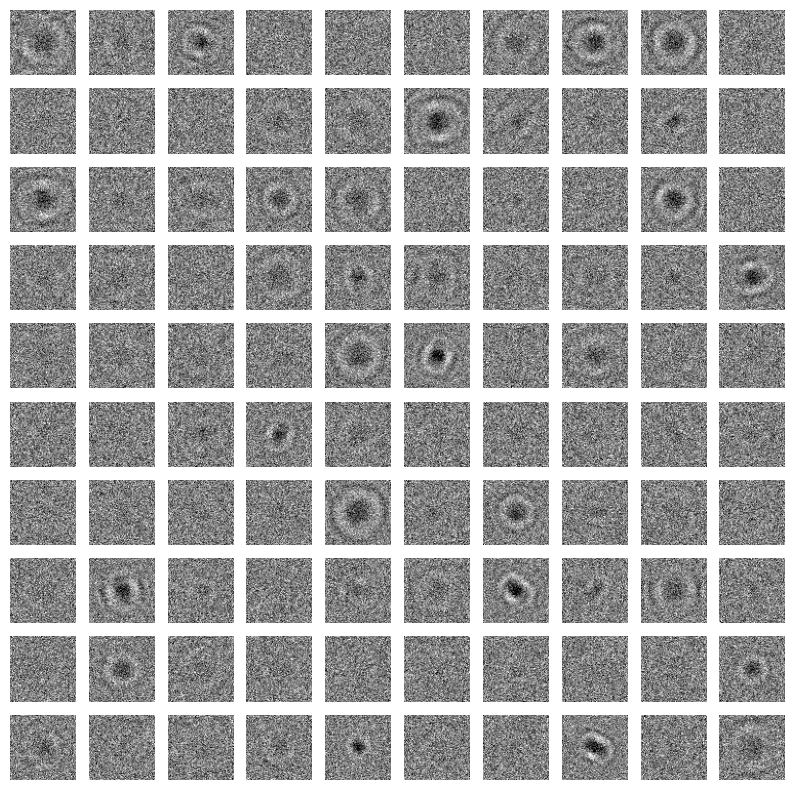

In [11]:
torch.save(images, "images.pt")

fig, axes = plt.subplots(10, 10, figsize=(10, 10), sharex=True, sharey=True)
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(images[idx], vmin=-3, vmax=3, cmap="gray")
    #ax.set_title(
    #    f"Side: {side_lengths[side_length[idx].round().long()].item():.2f}", fontsize=10
    #)
    ax.axis("off")

In [ ]:
images = torch.load('images.pt')
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(images[idx], vmin=-3, vmax=3, cmap="gray")
    #ax.set_title(
    #    f"Side: {side_lengths[side_length[idx].round().long()].item():.2f}", fontsize=10
    #)
    ax.axis("off")

### Train cryoSBI posterior

We will now train the cryoSBI posterior to infer the distance between the atoms from the simulated images.
The training is done with the function `npe_train_no_saving` which simulates images and simultaneously trains the posterior.
The function takes as input the config file `training_parameters.json` which contains the training and neural network parameters.
The function also takes as input the config file `simulation_parameters.json` which contains the simulation parameters used to simulate the images.


```
training_parameters_nle.json
```

```
{
    "EMBEDDING_X": "ConvEncoder_Tutorial",
    "EMBEDDING_THETA": "GNN",
    "OUT_DIM_X": 128,
    "OUT_DIM_THETA": 128,
    "NUM_TRANSFORM": 3,
    "NUM_HIDDEN_FLOW": 3,
    "HIDDEN_DIM_FLOW": 128,
    "MODEL": "NSF",
    "LEARNING_RATE": 0.0003,
    "CLIP_GRADIENT": 5.0,
    "BATCH_SIZE": 32
}
```


In [12]:
train_nle_model.nle_train_no_saving(
    "simulation_parameters.json",
    "training_parameters_nle.json",
    150,
    "tutorial_estimator_2.pt",  # name of the estimator file
    "tutorial_2.loss",  # name of the loss file
    n_workers=4,  # number of workers for data loading
    device="cuda",  # device to use for training and simulation
    saving_frequency=100,  # frequency of saving the model
    simulation_batch_size=160,  # batch size for simulation
)

/ziggy/cryoSBI/src/cryo_sbi/inference/train_nle_model.py:98: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models = torch.load(image_config["MODEL_FILE"]).to(device).to(torc

Training neural netowrk:


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [53:30<00:00, 21.40s/epoch, loss=-699]


/tmp/ipykernel_440806/3958503494.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  plt.plot(torch.load("tutorial_2.loss"))


Text(0, 0.5, 'Loss')

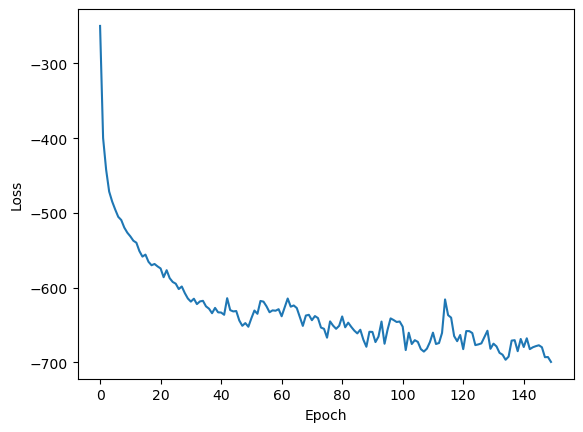

In [13]:
plt.plot(torch.load("tutorial_2.loss"))
plt.xlabel("Epoch")
plt.ylabel("Loss")

### Evaluate the posterior on our simulated images

We will now evaluate the trained posterior on our simulated images.
For each simulated image we will infer the distance between the atoms and compare it to the true distance, by sampling from the posterior.

In [ ]:
likelihood = est_utils.load_estimator(
    "training_parameters_nle.json",
    build_models.build_nle_flow_model,
    "tutorial_estimator.pt",
    device="cuda",
)

In [ ]:
samples = est_utils.sample_posterior(
    estimator=likelihood,
    images=images,
    num_samples=15000,
    batch_size=1000,
    device="cuda",
)

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for idx, ax in enumerate(axes.flatten()):
    ax.hist(samples[:, idx].flatten(), bins=np.linspace(0, simulator.max_index, 60))
    #ax.axvline(side_length[idx], ymax=1, ymin=0, color="red")
    ax.set_yticks([])
    ax.set_xticks([])

### Plot latent space

In [ ]:
latent_representations = est_utils.compute_latent_repr(
    estimator=likelihood,
    images=images,
    batch_size=1000,
    device="cuda",
)

In [ ]:
reducer = umap.UMAP(metric="euclidean", n_components=2, n_neighbors=50)
latent_vecs_transformed = reducer.fit_transform(latent_representations.numpy())

In [ ]:
plt.scatter(
    latent_vecs_transformed[:, 0],
    latent_vecs_transformed[:, 1],
    c=side_length,
    cmap="viridis",
    s=10,
)
plt.colorbar(label="Side length")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

In [ ]:
device = 'cpu'
estimator = est_utils.load_estimator(
    "training_parameters_nle.json",
    build_models.build_nle_flow_model,
    "tutorial_estimator.pt",
    device="cuda",
)

In [ ]:
log_probs = []
for model_batch in models:
    posterior = estimator.flow(model_batch.to(device))
    log_probs.append(posterior.log_prob(images))

log_probs = torch.cat(log_probs, dim=1)